# 04. Statistical Hypothesis Testing

## Overview
Beyond visual observation, we need statistical rigor to confirm if our findings are significant or merely due to random chance.

## Objectives:
1. **T-Testing**: Compare numerical distributions (Salary, Usage) between groups.
2. **Chi-Square Analysis**: Test independence of categorical features (Partner, State) vs Churn.
3. **Conclusion**: Rank the top drivers of customer attrition.

In [6]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/telecom_churn_cleaned.csv")
print("Data loaded for statistical validation.")

Data loaded for statistical validation.


## 1. Do High Earners Churn Less?
**Null Hypothesis ($H_0$)**: There is no difference in estimated salary between churned and retained customers.

In [8]:
churned_salary = df[df['churn'] == 1]['estimated_salary']
retained_salary = df[df['churn'] == 0]['estimated_salary']

t_stat, p_val = stats.ttest_ind(churned_salary, retained_salary, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("REJECT NULL: Salary is a statistically significant driver of churn.")
else:
    print("FAIL TO REJECT: No evidence that salary impacts churn significantly.")

T-Statistic: 0.9186
P-Value: 0.3583
FAIL TO REJECT: No evidence that salary impacts churn significantly.


## 2. Categorical Association: Gender vs Churn
Does gender play a role in the decision to switch providers?

In [9]:
contingency = pd.crosstab(df['gender'], df['churn'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-Square: {chi2:.4f}")
print(f"P-Value: {p:.4f}")

if p < 0.05:
    print("Significant association found between Gender and Churn.")
else:
    print("Gender appears to be independent of Churn behavior.")

Chi-Square: 0.0000
P-Value: 0.9956
Gender appears to be independent of Churn behavior.


In [10]:
# Create the composite usage score again for statistical testing
df['usage_score'] = df['calls_made'] + df['sms_sent'] + (df['data_used'] / 100)

churned_usage = df[df['churn'] == 1]['usage_score']
retained_usage = df[df['churn'] == 0]['usage_score']

# Run the Two-Sample T-Test
t_stat, p_val = stats.ttest_ind(churned_usage, retained_usage, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("REJECT NULL: Usage engagement is a statistically significant driver of churn.")
else:
    print("FAIL TO REJECT: No mathematical evidence that usage score impacts churn.")


T-Statistic: -47.2370
P-Value: 0.0000
REJECT NULL: Usage engagement is a statistically significant driver of churn.


In [12]:
# Run a Chi-Square test of independence to see if State truly affects Churn
contingency_state = pd.crosstab(df['state'], df['churn'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_state)

print(f"Chi-Square: {chi2:.4f}")
print(f"P-Value: {p:.4f}")

if p < 0.05:
    print("Significant association found between State and Churn.")
else:
    print("FAIL TO REJECT: Churn appears to be independent of Regional Geography.")


Chi-Square: 22.4530
P-Value: 0.7140
FAIL TO REJECT: Churn appears to be independent of Regional Geography.


## 3. KPI Business Metrics
Translating statistical findings into measurable business impact.


In [13]:
# --- KPI 1: Overall Churn Rate ---
overall_churn_rate = df['churn'].mean() * 100
print(f"📊 Overall Churn Rate: {overall_churn_rate:.2f}%")

# --- KPI 2: Churn Rate by Telecom Partner ---
print("\n📊 Churn Rate by Telecom Partner:")
print(df.groupby('telecom_partner')['churn'].mean().mul(100).round(2).to_string())

# --- KPI 3: Average Usage Score - Churned vs Retained ---
df['usage_score'] = df['calls_made'] + df['sms_sent'] + (df['data_used'] / 100)
churned_avg_usage = df[df['churn'] == 1]['usage_score'].mean()
retained_avg_usage = df[df['churn'] == 0]['usage_score'].mean()
usage_gap = retained_avg_usage - churned_avg_usage

print(f"\n📊 Avg Usage Score — Churned Customers:  {churned_avg_usage:.2f}")
print(f"📊 Avg Usage Score — Retained Customers: {retained_avg_usage:.2f}")
print(f"📊 Engagement Gap (Retained - Churned):  {usage_gap:.2f}")

# --- KPI 4: Revenue at Risk ---
total_customers = len(df)
churned_customers = df['churn'].sum()
avg_salary = df['estimated_salary'].mean()
revenue_at_risk = churned_customers * (avg_salary * 0.02)  # Assume ARPU = 2% of salary
print(f"\n📊 Total Customers: {total_customers:,}")
print(f"📊 Customers Lost to Churn: {churned_customers:,}")
print(f"📊 Estimated Annual Revenue at Risk: ₹{revenue_at_risk:,.0f}")


📊 Overall Churn Rate: 19.53%

📊 Churn Rate by Telecom Partner:
telecom_partner
Airtel          15.76
BSNL            29.57
Reliance Jio    11.04
Vodafone        21.81

📊 Avg Usage Score — Churned Customers:  115.04
📊 Avg Usage Score — Retained Customers: 125.44
📊 Engagement Gap (Retained - Churned):  10.40

📊 Total Customers: 243,553
📊 Customers Lost to Churn: 47,562
📊 Estimated Annual Revenue at Risk: ₹80,875,507


## 4. Correlation Analysis
Which numerical features are most linearly associated with churn?


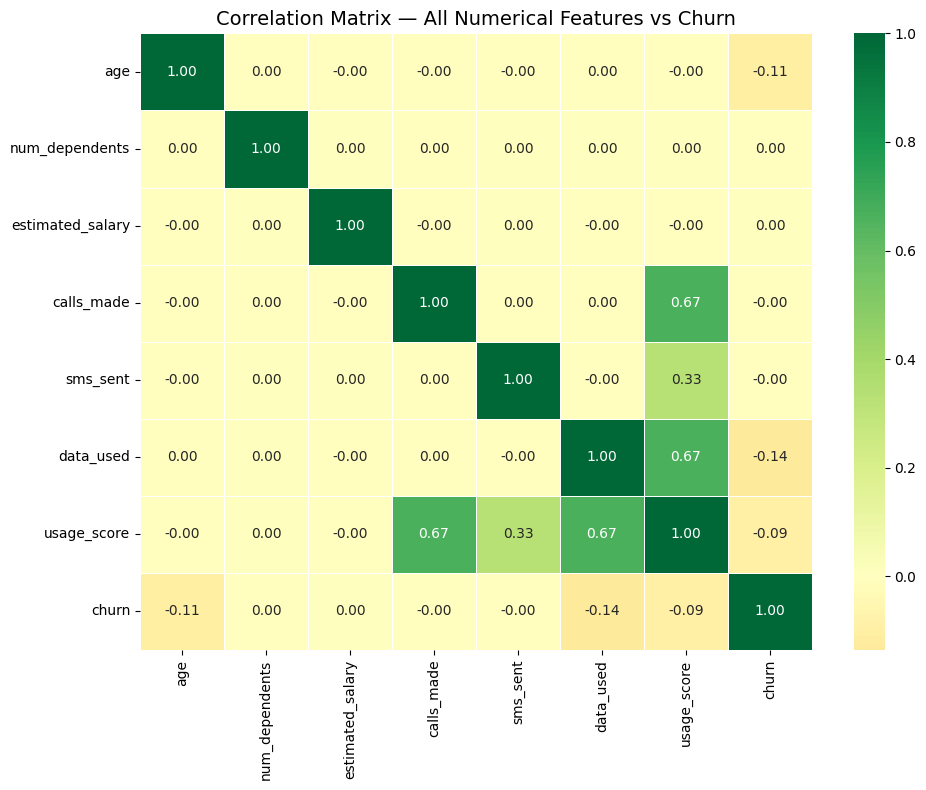

In [14]:
# Select only the numerical columns relevant to churn
numerical_cols = ['age', 'num_dependents', 'estimated_salary', 
                  'calls_made', 'sms_sent', 'data_used', 'usage_score', 'churn']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdYlGn', 
            center=0, linewidths=0.5)
plt.title('Correlation Matrix — All Numerical Features vs Churn', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Logistic Regression — Churn Probability Model
Which features are statistically significant predictors of churn? 
This model gives us odds ratios — the most decision-relevant output.


In [15]:
import statsmodels.api as sm

# Prepare features
df['usage_score'] = df['calls_made'] + df['sms_sent'] + (df['data_used'] / 100)
X = df[['age', 'estimated_salary', 'num_dependents', 'usage_score']]
X = sm.add_constant(X)
y = df['churn']

# Fit Logistic Regression
model = sm.Logit(y, X).fit()
print(model.summary())

# Calculate and display Odds Ratios
print("\n--- Odds Ratios (How Each Variable Affects Churn Probability) ---")
odds_ratios = pd.DataFrame({
    'Odds Ratio': np.exp(model.params),
    'P-Value':    model.pvalues
}).round(4)
print(odds_ratios)


Optimization terminated successfully.
         Current function value: 0.483610
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:               243553
Model:                          Logit   Df Residuals:                   243548
Method:                           MLE   Df Model:                            4
Date:                Sat, 25 Apr 2026   Pseudo R-squ.:                 0.02062
Time:                        12:25:45   Log-Likelihood:            -1.1778e+05
converged:                       True   LL-Null:                   -1.2027e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0134      0.025     -0.539      0.590      -0.062       0.035
age        